# Predicción de mora temprana en microcréditos MYPE
**Notebook 01 · Problema, dataset y análisis exploratorio**

Orden de ejecución del proyecto: `01` → `02` → `03`.

## 1. Definición del problema

**Contexto:** 

Las microfinancieras peruanas en su mayoria son cajas municipales que financian a micro y pequeñas empresas (MYPE) que en muchas ocasiones funcionan de manera informal y no cuentan con registros financieros ordenados. Ademas, generar una buena evaluacion crediticia es dificil, pues la estimacion del asesor de negocios depende de la información declarada por el cliente, lo cual, a su vez, genera dificultad de anticipar qué creditos no seran pagados. Ademas, se sabe que en los ultimos años la morosidad de las microempresas ha aumentado, obligando a las entidades a constituir mayores provisiones y reduciendo su rentabilidad para las MYPEs.

**Necesidad.** El comite de creditos necesita una estimacion objetiva del riesgo de mora de cada solicitud, construida con la información disponible al momento de la evaluacion, que complemente el analisis del asesor.


**Unidad de análisis.** Un credito MYPE desembolsado. Un mismo cliente puede tener varios creditos.

**Pregunta principal.** ¿Puede un modelo estimar, al momento de la evaluacion, la probabilidad de que un credito MYPE supere los 30 dias de atraso en sus primeros 6 meses, mejor que una regla simple?

![Línea de decisión de un microcrédito](..\reports\figures\LineaPrestamo.png)


**Tipo de problema.** Clasificacion binaria supervisada. La variable objetivo toma el valor 1 si el credito registra mas de 30 dias de atraso en algun momento de sus primeros 6 meses desde el desembolso, y 0 en caso contrario. Las clases estan desbalanceadas (~11 % de creditos en mora). El umbral de 30 dias coincide con el paso de un deudor a la categoria "Deficiente" en la clasificacion de la SBS para microempresas.

**Usuario y uso.** El comite de creditos. Para cada solicitud, el modelo entrega una probabilidad de mora que complementa el analisis del asesor de negocios. Solo utiliza variables conocidas antes del desembolso, de modo que pueda aplicarse en la evaluacion real. La decision final de aprobar, ajustar o rechazar sigue siendo del comite.

**Utilidad esperada.** Identificar con anticipacion las solicitudes de mayor riesgo para ajustar sus condiciones (monto, plazo, garantias) o reforzar su evaluacion, reduciendo la mora y las provisiones asociadas sin restringir innecesariamente el acceso al credito de los buenos pagadores.

**Criterios de utilidad.** Aprobar a un cliente que cae en mora (falso negativo) es mas costoso que rechazar a un buen pagador (falso positivo), porque implica perder capital y no solo intereses. Por ello, el resultado se considerara util si:
- supera claramente al baseline en metricas adecuadas al desbalance (por ejemplo, AUC-ROC, AUC-PR), y no solo en accuracy
- detecta una proporcion relevante de los creditos que caen en mora
- mantiene un nivel razonable de falsos positivos, para no rechazar en exceso a buenos pagadores


## 2. Dataset y procedencia

- **Fuente y procedencia:** dataset sintético generado por el grupo con `src/generar_datos.py`, con autorización del docente. Simula los créditos MYPE desembolsados por una entidad microfinanciera peruana.
- **Número de observaciones y variables:** 15,579 filas y 35 columnas (ver celda de carga).
- **Período temporal:** desembolsos entre enero de 2022 y diciembre de 2024, con corte de extracción al 30/06/2025.
- **Variable objetivo:** `mora_30d_6m`, que vale 1 si el crédito superó 30 días de atraso en sus primeros 6 meses y 0 en caso contrario.
- **Variables principales:** perfil del titular, datos del negocio, historial en el sistema financiero (buró y SBS) y condiciones del crédito. El detalle está en `data/diccionario_datos.md`.
- **Licencia o condiciones de uso:** al ser generado por el grupo, no tiene licencias de terceros; su uso está autorizado en el marco del curso.
- **Limitaciones conocidas:** los datos son sintéticos, así que las conclusiones no se pueden extrapolar a la población real. Solo hay créditos aprobados (no se sabe cómo habrían pagado los rechazados), un mismo cliente puede tener varios créditos y dos variables (`num_gestiones_cobranza` y `estado_credito_corte`) se registran después del desembolso, por lo que no pueden usarse en el modelo.
- **Justificación:** tiene una variable objetivo alineada con el criterio de la SBS (más de 30 días de atraso = categoría "Deficiente"), variables disponibles al momento de evaluar la solicitud y suficientes registros para separar train, validation y test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/creditos_mype.csv")
df.shape

(15579, 35)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15579 entries, 0 to 15578
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_credito                    15579 non-null  str    
 1   id_cliente                    15579 non-null  str    
 2   fecha_solicitud               15579 non-null  str    
 3   fecha_desembolso              15579 non-null  str    
 4   region                        15579 non-null  str    
 5   codigo_asesor                 15579 non-null  str    
 6   canal_captacion               15579 non-null  str    
 7   edad                          15579 non-null  int64  
 8   sexo                          15579 non-null  str    
 9   estado_civil                  15579 non-null  str    
 10  nivel_educativo               14294 non-null  str    
 11  tipo_vivienda                 15579 non-null  str    
 12  num_dependientes              15579 non-null  int64  
 13  rubro       

In [3]:
# Valores faltantes por columna
faltantes = df.isna().sum()
faltantes[faltantes > 0]

nivel_educativo              1285
antiguedad_negocio_meses      671
ingreso_mensual_declarado     391
gasto_mensual_declarado       626
score_buro                   2417
telefono_verificado           466
dtype: int64

In [4]:
# Período cubierto (las fechas vienen en dos formatos distintos)
fechas = pd.to_datetime(df["fecha_desembolso"], format="mixed", dayfirst=True)
print("Primer desembolso:", fechas.min().date())
print("Último desembolso:", fechas.max().date())
print("Créditos únicos:", df["id_credito"].nunique(), "| Clientes únicos:", df["id_cliente"].nunique())

Primer desembolso: 2022-01-01
Último desembolso: 2024-12-30
Créditos únicos: 15395 | Clientes únicos: 11500


**Interpretación:** el dataset tiene 15,579 filas pero solo 15,395 créditos únicos, así que hay registros duplicados. Además, hay 11,500 clientes para esos créditos, lo que confirma que varios clientes tienen más de un crédito. Las fechas aparecen en dos formatos (AAAA-MM-DD y DD/MM/AAAA) y `ingreso_mensual_declarado` no se lee como número. Hay faltantes en seis variables, sobre todo en `score_buro`. Estos problemas no se corrigen aquí: se registran en la sección 3.8 y se tratan en el notebook 02.

## 3. Análisis exploratorio

### 3.1 Variable objetivo

mora_30d_6m
0    0.8914
1    0.1086
Name: proportion, dtype: float64


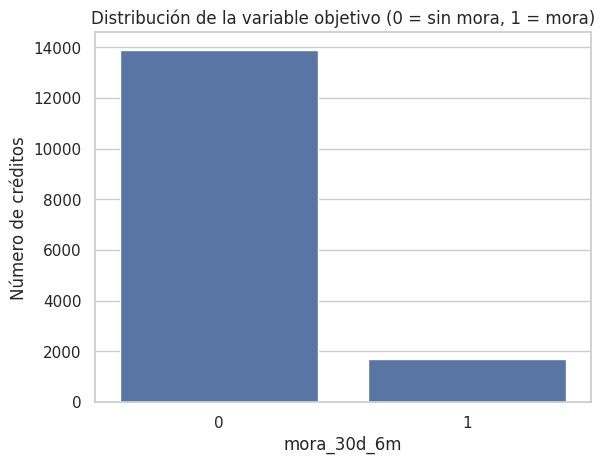

In [5]:
print(df["mora_30d_6m"].value_counts(normalize=True).round(4))

sns.countplot(x=df["mora_30d_6m"])
plt.title("Distribución de la variable objetivo (0 = sin mora, 1 = mora)")
plt.xlabel("mora_30d_6m")
plt.ylabel("Número de créditos")
plt.show()

**Interpretación:** la variable objetivo está desbalanceada: el 10.9% de los créditos cae en mora y el 89.1% no. Un modelo que nunca predijera mora tendría una accuracy de 89% sin detectar a ningún moroso, por lo que la accuracy no sirve para evaluar este problema. La evaluación deberá centrarse en métricas que midan la detección de los créditos en mora, como el recall, la precisión y el ROC-AUC.

### 3.2 Distribución de las variables numéricas

In [6]:
# Conversión mínima de ingresos para poder graficarlos (algunos vienen como "S/ 1,500.00")
ingreso_num = pd.to_numeric(
    df["ingreso_mensual_declarado"].astype(str).str.replace("S/", "", regex=False).str.replace(",", "", regex=False).str.strip(),
    errors="coerce",
)

numericas = df[["monto_aprobado", "cuota_mensual", "score_buro", "edad", "tasa_interes_anual", "antiguedad_negocio_meses"]].copy()
numericas["ingreso_mensual"] = ingreso_num
numericas.describe().round(1)

,monto_aprobado,cuota_mensual,score_buro,edad,tasa_interes_anual,antiguedad_negocio_meses,ingreso_mensual
count,15579.0,15579.0,13162.0,15579.0,15579.0,14908.0,15188.0
mean,8335.5,787.2,620.2,44.0,57.6,59.4,4233.0
std,7609.2,651.4,111.6,53.6,9.7,38.1,4218.5
min,400.0,31.6,300.0,15.0,0.3,-1.0,390.0
25%,3500.0,381.9,545.0,34.0,53.1,34.0,2260.0
50%,6100.0,613.2,621.5,41.0,58.4,50.0,3400.0
75%,10500.0,960.7,696.0,48.0,63.5,75.0,5110.0
max,67300.0,10224.3,950.0,999.0,85.6,365.0,143100.0


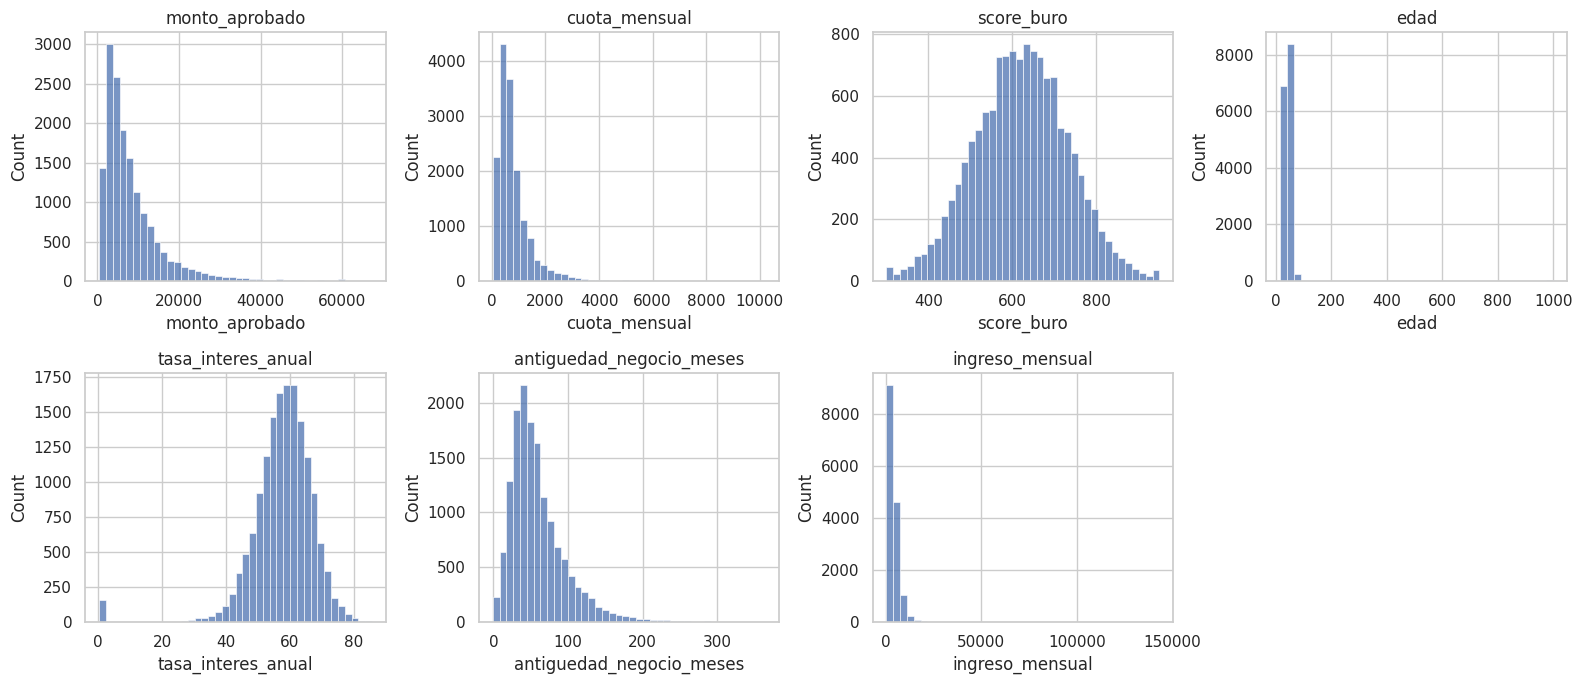

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, numericas.columns):
    sns.histplot(numericas[col].dropna(), bins=40, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

**Interpretación:** las variables monetarias son asimétricas a la derecha. Por ejemplo, el monto aprobado tiene una media de S/ 8,336 y una mediana de S/ 6,100, y el ingreso mensual llega hasta S/ 143,100, muy lejos del valor típico. Por eso, la mediana describe mejor el caso típico que la media. `score_buro` tiene una distribución casi simétrica dentro del rango 300–950. También aparecen valores imposibles: edades de 999 y menores de 18, antigüedad del negocio negativa y tasas de interés menores a 1, que parecen registradas como fracción (0.58) en lugar de porcentaje (58).

### 3.3 Distribución de las variables categóricas

region: 25 categorías distintas
rubro: 16 categorías distintas
sexo: 4 categorías distintas
canal_captacion: 3 categorías distintas


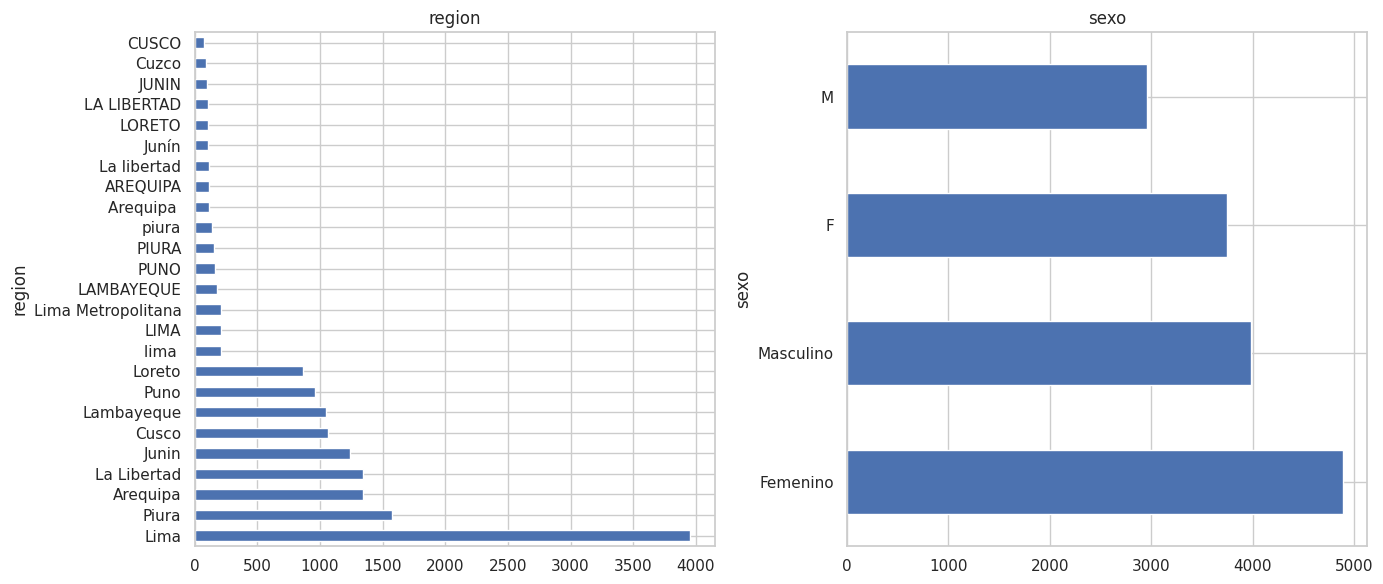

In [8]:
for col in ["region", "rubro", "sexo", "canal_captacion"]:
    print(f"{col}: {df[col].nunique()} categorías distintas")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df["region"].value_counts().plot(kind="barh", ax=axes[0], title="region")
df["sexo"].value_counts().plot(kind="barh", ax=axes[1], title="sexo")
plt.tight_layout()
plt.show()

In [9]:
# ¿Los score_buro vacíos coinciden con la categoría "Sin historial"?
pd.crosstab(df["calificacion_sbs"], df["score_buro"].isna(), colnames=["score_buro vacío"])

score_buro vacío,False,True
calificacion_sbs,,
CPP,1766,0
Deficiente,802,0
Dudoso,414,0
Normal,9930,0
Perdida,250,0
Sin historial,0,2417


**Interpretación:** `region` tiene 25 categorías distintas y `rubro` 16, cuando en realidad son 9 regiones y 5 rubros: la misma categoría aparece escrita de varias formas (por ejemplo, "Lima", "LIMA" y "lima "). `sexo` mezcla "F" y "M" con "Femenino" y "Masculino". Sin unificarlas, el modelo trataría cada variante como un grupo distinto. Además, todos los `score_buro` vacíos corresponden a la categoría "Sin historial", por lo que ese faltante no es un error: indica que el cliente no tiene historial crediticio.

### 3.4 Relación de las variables con la mora

#### 3.4.1 Pregunta: ¿Cómo impacta el puntaje crediticio en la tasa de mora?

/tmp/ipykernel_138/2620113035.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tasa_mora_score, x='score_quintil', y='mora_30d_6m', palette="viridis")


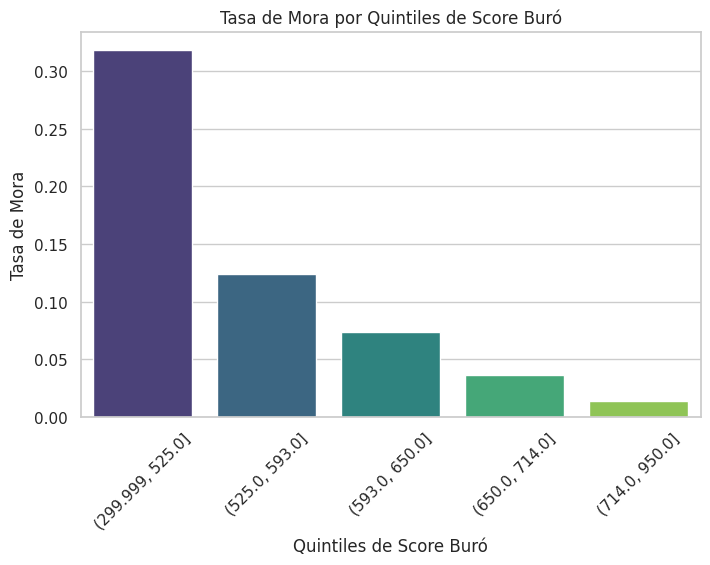

In [10]:
df['score_quintil'] = pd.qcut(df['score_buro'], q=5)
tasa_mora_score = df.groupby('score_quintil', observed=True)['mora_30d_6m'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=tasa_mora_score, x='score_quintil', y='mora_30d_6m', palette="viridis")
plt.title('Tasa de Mora por Quintiles de Score Buró')
plt.xlabel('Quintiles de Score Buró')
plt.ylabel('Tasa de Mora')
plt.xticks(rotation=45)
plt.show()

**Interpretación:** Los datos muestran que el score es un excelente discriminador. Al dividir el "score_buro" en quintiles, el 20% con menor score presenta una mora del 31.8%. En contraste, el 20% con mayor score registra apenas en 1.3% de mora. A menor puntaje. el riesgo de mora se dispara de forma casi exponencial.

#### 3.4.2 Pregunta: ¿Afecta la carga de la cuota mensual sobre los ingresos a la probabilidad de mora?

/tmp/ipykernel_138/1964002287.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tasa_mora_carga, x='carga_quintil', y='mora_30d_6m', palette="magma")


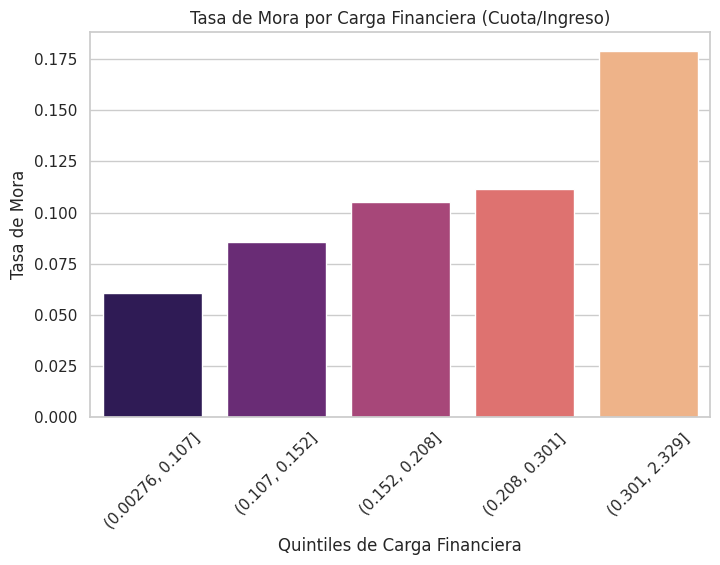

In [11]:
ingreso_num = pd.to_numeric(
    df["ingreso_mensual_declarado"].astype(str).str.replace("S/", "", regex=False).str.replace(",", "", regex=False).str.strip(), 
    errors="coerce"
)
df['carga_cuota'] = df['cuota_mensual'] / ingreso_num
df['carga_quintil'] = pd.qcut(df['carga_cuota'], q=5)

tasa_mora_carga = df.groupby('carga_quintil', observed=True)['mora_30d_6m'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=tasa_mora_carga, x='carga_quintil', y='mora_30d_6m', palette="magma")
plt.title('Tasa de Mora por Carga Financiera (Cuota/Ingreso)')
plt.xlabel('Quintiles de Carga Financiera')
plt.ylabel('Tasa de Mora')
plt.xticks(rotation=45)
plt.show()

**Interpretación:** Existe una relación directa clara. El quintil con menor carga de cuota tiene un 6% de mora. Sin embargo, el quintil con mayor carga alcanza el 17.9% de mora. Los clientes que comprometen una proporción demasiado alta de sus ingresos mensuales tienen más del doble de probabilidad de caer en mora.

#### 3.4.3 Pregunta: ¿El historial de dias de atraso predice la mora del nuevo crédrito?

/tmp/ipykernel_138/3800354369.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tasa_mora_atraso, x='rango_atraso', y='mora_30d_6m', palette="rocket")


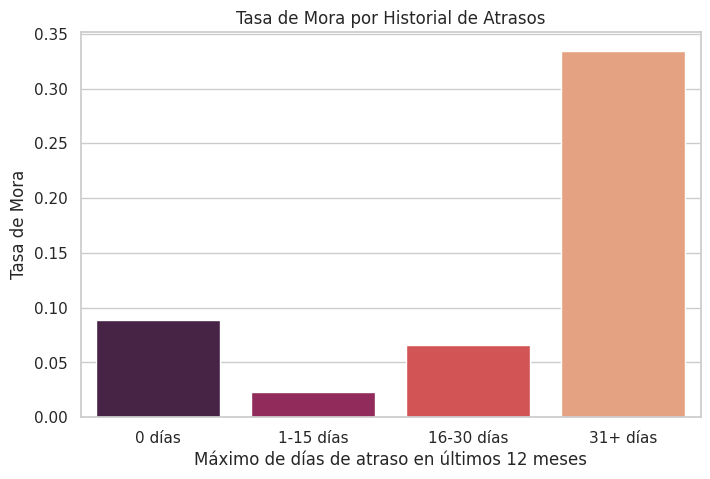

In [12]:
bins = [-1, 0, 15, 30, 999]
labels = ['0 días', '1-15 días', '16-30 días', '31+ días']
df['rango_atraso'] = pd.cut(df['max_dias_atraso_12m'], bins=bins, labels=labels)

tasa_mora_atraso = df.groupby('rango_atraso', observed=True)['mora_30d_6m'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=tasa_mora_atraso, x='rango_atraso', y='mora_30d_6m', palette="rocket")
plt.title('Tasa de Mora por Historial de Atrasos')
plt.xlabel('Máximo de días de atraso en últimos 12 meses')
plt.ylabel('Tasa de Mora')
plt.show()

**Interpretación:** Un historial con más de 30 dias de atraso es una alerta roja crítica. Los clientes con 0 dias de atraso histórico tienen un 8.8% de mora. La baja mora en el rango de 1 a 15 dias sugiera que pequeños atrasos pueden ser operativos o que el comité evaluador fue extremadamente selectivo y aplicó condiciones más estrictas para aprobar a ese grupo.

### 3.5 Diferencias entre grupos

#### Pregunta: ¿Existen diferencias en el nivel de riesgo según el canala de captación?

/tmp/ipykernel_138/614563714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tasa_mora_canal, x='canal_captacion', y='mora_30d_6m', palette="coolwarm")


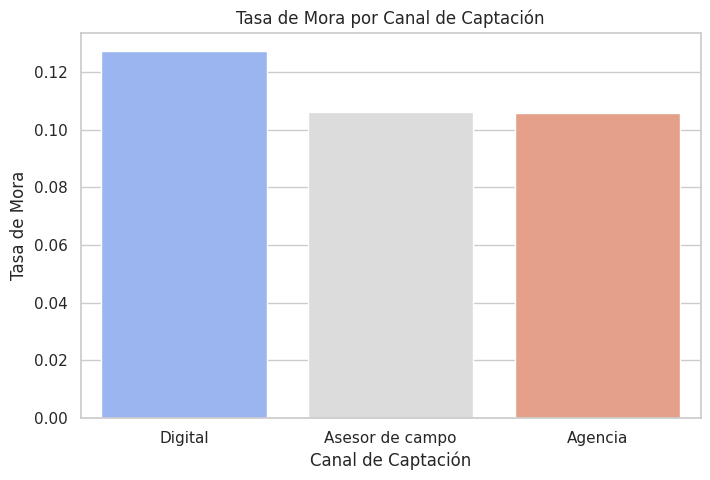

In [13]:
tasa_mora_canal = df.groupby('canal_captacion')['mora_30d_6m'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=tasa_mora_canal, x='canal_captacion', y='mora_30d_6m', palette="coolwarm")
plt.title('Tasa de Mora por Canal de Captación')
plt.xlabel('Canal de Captación')
plt.ylabel('Tasa de Mora')
plt.show()

**Interpretación:** El canal digital atrae un perfil ligeramente más riesgoso o sufre por falta de un filtro presencial humano, frente a "Asesor de campo" y "Agencia". Además, al explorar los datos crudos de otras agrupaciones, se evidencia que categorías como región o rubro requerirán unificación en el proceso de limpieza antes de incluirlas en el modelo.

### 3.6 Evolución en el tiempo

#### Pregunta: ¿Cómo varió la proporción de créditos en mora según el trimestre de desembolso?

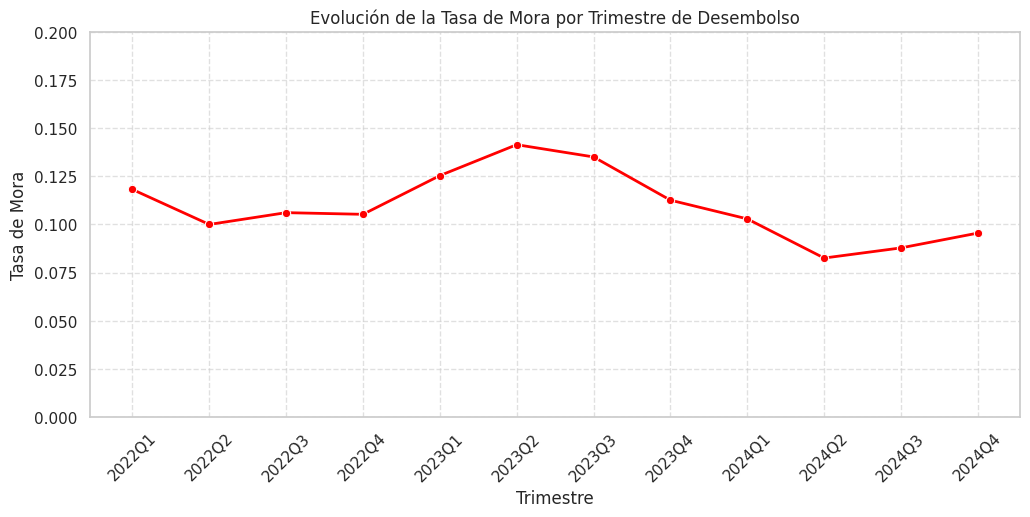

In [14]:
fecha_desemb = pd.to_datetime(df['fecha_desembolso'], format="mixed", dayfirst=True, errors='coerce')
df['trimestre_desembolso'] = fecha_desemb.dt.to_period('Q').astype(str)

tasa_mora_tiempo = df.groupby('trimestre_desembolso')['mora_30d_6m'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=tasa_mora_tiempo, x='trimestre_desembolso', y='mora_30d_6m', marker='o', color='red', linewidth=2)
plt.title('Evolución de la Tasa de Mora por Trimestre de Desembolso')
plt.xlabel('Trimestre')
plt.ylabel('Tasa de Mora')
plt.xticks(rotation=45)
plt.ylim(0, 0.2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Interpretación:** El nivel de riesgo del portafolio no es estático. Inicia en ~10-11% en 2022, sube fuertemenet hasta alcanzar un pico de 14.4% en el tercer trimestre de 2023, y desciende a niveles de 8-9% durante 2024. Esta inestabilidad justifica no utilizar un split aleatorio tradicional para el entrenamiento, ya que mezclaría coyunturas económicas y de políticas crediciticas distintas. Se debe usar una separación temporal para evaluar el modelo bajo condiciones reales.

### 3.7 Relaciones entre variables explicativas

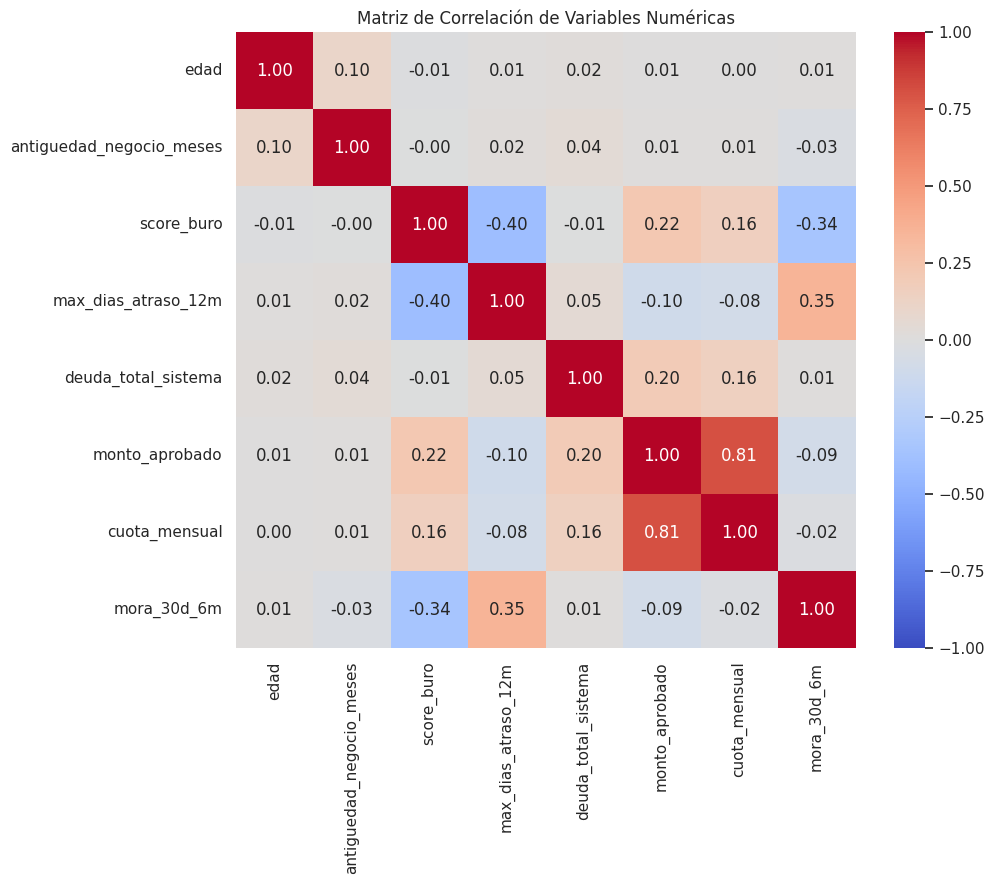

In [15]:
num_cols = ['edad', 'antiguedad_negocio_meses', 'score_buro', 'max_dias_atraso_12m', 
            'deuda_total_sistema', 'monto_aprobado', 'cuota_mensual', 'mora_30d_6m']

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Interpretación:** La variable tiene una correlación lineal negativa destacable con "score_buro" y una positiva con "max_dias_atraso_12m". Las variables demográficas y de las condiciones del crédito tienen correlaciones lineales casi nulas con la mora. Esto confirma que el riesgo surge de interacciones multidimensionales, exigiendo el uso de modelos como árboles de decisión o ensambles en la fase predictiva.

### 3.8 Patrones, anomalías y problemas de calidad observados

| Hallazgo | Evidencia | Posible explicación | Decisión que condiciona |
|---|---|---|---|
|Fechas en múltiples formatos|"fecha_solicitud" y "fecha_desembolso" mezclan formatos ISO y DD/MM/AAAA|Exportación de distintos sistemas core o carga manual combinada.|Parseo explícito de ambos formatos antes del modelado.|
|Categorías duplicadas y sucias|Región, rubro y sexo muestran variantes por mayúsculas, minúsculas, espacios y tildes.|Texto libre o múltiples interfaces de digitación en las agencias.|Obliga a crear un mapa de normalización semántica explícita|
|Nulos estructurales en Score|Hay clientes sin score_buro, y todos coinciden exactamente con la categoría "Sin historial".|El buró no devuelve puntaje a clientes no bancarizados.|No se puede borrar ni rellenar con la media; exige usar indicadores de "score ausente".|
|Outliers y errores de dominio|Presencia de edades de 15 o 999 años, y tasas de interés anual expresadas como fracción (<1)|Error de digitación evidente (999) o confusión en la escala (decimal vs porcentaje)|Marcar edades imposibles como nulos y multiplicar tasas pequeñas por 100|

### 3.9 Síntesis del EDA

- **Hallazgos principales:** Nos enfrentamos a un problema fuertemente desbalanceado, con una clase minoritaria de mora cercana al 11%. Existe una variación notable de la mora a través del tiempo y diferencias marcadas según si el cliente fue captado por canala digital o por agencia física.
- **Variables que parecen más relacionadas con la mora** (y la precaución al afirmarlo): El puntaje de la central de riesgo y el máximo de días de atraso en el último año. Construir variables de ratio, como la carga financiera de la cuota respecto a los ingresos, añade una señal importante.
- **Implicancias para la preparación y el modelado:** La base cruda necesita una corección profunda de tipos, duplicados y categorización antes de hacer cualquier cruce. Además, dada la evolución temporal de la morosidad y las reglas del negocio, el modelo debe ser entrenado preservando el orden cronológico y se deben remover del entrenamiento las variables de cobranza y estados futuros provocan fuga de información.
- **Lo que aún no puede concluirse:** Todavía no está claro el peso simultáneo de las características del cliente, ya que las correlaciones lineales mostraron señales debiles para ingresos y montos. Tampoco se puede saber de antemano el impacto que generará en la precisión imputar la información crítica faltante, como la antigüedad del negocio que carece de datos principalmente en los canales digitales.